This notebook performs initial data processing and prepares input for "6. Multiome 2 - Fig. 3B-C, 3G-J, S4A-D, S5A-B".

## Setup

In [1]:
renv::load('/oak/stanford/groups/agitler/Shared/Shared_Jupyter_Notebook_Analysis/4.1.1-OG-Multiome/')

library(ArchR)
library(future)
library(dplyr)
library(BSgenome.Mmusculus.UCSC.mm10)
library(pheatmap)
library(ggpubr)
library(ggrepel)
library(ggbreak)
library(cowplot)
library(Seurat)
library(forcats)

if(!dir.exists('/oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome')){
  dir.create('/oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome')
}
setwd('/oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome')

addArchRGenome("mm10")

plan(strategy = "multicore", workers = 16)
options(future.globals.maxSize = 41953040000)

addArchRThreads(threads = 16)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

## Prepare ArchR project

In [2]:
#Get Input Fragment Files
sample1 <- '/oak/stanford/groups/agitler/Olivia/single_cell_data/10X_analyzed/SOD1_multiome/5_25_sample1/outs/atac_fragments.tsv.gz'
sample2 <- '/oak/stanford/groups/agitler/Olivia/single_cell_data/10X_analyzed/SOD1_multiome/6_3_sample1/outs/atac_fragments.tsv.gz'
sample3 <- '/oak/stanford/groups/agitler/Olivia/single_cell_data/10X_analyzed/SOD1_multiome/6_3_sample2/outs/atac_fragments.tsv.gz'
sample4 <- '/oak/stanford/groups/agitler/Olivia/single_cell_data/10X_analyzed/SOD1_multiome/12_22_sample1/outs/atac_fragments.tsv.gz'
sample5 <- '/oak/stanford/groups/agitler/Olivia/single_cell_data/10X_analyzed/SOD1_multiome/12_22_sample2/outs/atac_fragments.tsv.gz'

inputFiles <- c(sample1_5_25=sample1, sample1_6_3=sample2, sample2_6_3=sample3, sample1_12_22=sample4, sample2_12_22=sample5)

In [3]:
#Create Arrow Files 
ArrowFiles <- createArrowFiles(
  inputFiles = inputFiles,
  sampleNames = names(inputFiles),
)

Using GeneAnnotation set by addArchRGenome(Mm10)!

Using GeneAnnotation set by addArchRGenome(Mm10)!

ArchR logging to : ArchRLogs/ArchR-createArrows-79b2351fda86-Date-2024-04-12_Time-15-33-25.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

2024-04-12 15:33:25 : Batch Execution w/ safelapply!, 0 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-createArrows-79b2351fda86-Date-2024-04-12_Time-15-33-25.log



In [4]:
#ArchRProject
proj <- ArchRProject(ArrowFiles)

Using GeneAnnotation set by addArchRGenome(Mm10)!

Using GeneAnnotation set by addArchRGenome(Mm10)!

Validating Arrows...

Getting SampleNames...



Copying ArrowFiles to Ouptut Directory! If you want to save disk space set copyArrows = FALSE

1 
2 
3 
4 
5 


Getting Cell Metadata...



Merging Cell Metadata...

Initializing ArchRProject...


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
      

In [5]:
#Get Input RNA Files
sample1_rna <- '/oak/stanford/groups/agitler/Olivia/single_cell_data/10X_analyzed/SOD1_multiome/5_25_sample1/outs/filtered_feature_bc_matrix.h5'
sample2_rna <- '/oak/stanford/groups/agitler/Olivia/single_cell_data/10X_analyzed/SOD1_multiome/6_3_sample1/outs/filtered_feature_bc_matrix.h5'
sample3_rna <- '/oak/stanford/groups/agitler/Olivia/single_cell_data/10X_analyzed/SOD1_multiome/6_3_sample2/outs/filtered_feature_bc_matrix.h5'
sample4_rna <- '/oak/stanford/groups/agitler/Olivia/single_cell_data/10X_analyzed/SOD1_multiome/12_22_sample1/outs/filtered_feature_bc_matrix.h5'
sample5_rna <- '/oak/stanford/groups/agitler/Olivia/single_cell_data/10X_analyzed/SOD1_multiome/12_22_sample2/outs/filtered_feature_bc_matrix.h5'

inputFiles_rna <- c(sample1_rna, sample2_rna, sample3_rna, sample4_rna, sample5_rna)

In [6]:
# Import scRNA
seRNA <- import10xFeatureMatrix(
    input = inputFiles_rna,
    names = names(inputFiles),
    strictMatch = FALSE
)

Importing Feature Matrix 1 of 5

Importing Feature Matrix 2 of 5

Importing Feature Matrix 3 of 5

Importing Feature Matrix 4 of 5

Importing Feature Matrix 5 of 5

Re-ordering RNA matricies for consistency.

Merging individual RNA objects...


Merging sample1_6_3

Warning! Some values within column "id" of the rowData (gene metadata) of your objects do not precisely match!

This is often caused by slight variations in Ensembl IDs and gene locations used by cellranger across different samples. ArchR will ignore these mismatches and allow merging to proceed but you should check to make sure that these are ok for your data.


Mismatch in column "id" row 25927 for sample1_6_3: ENSMUSG00000116160 does not exactly match ENSMUSG00000116253!

strictMatch = FALSE so mismatching information will be coerced to match the first sample provided.


Merging sample2_6_3

Warning! Some values within column "id" of the rowData (gene metadata) of your objects do not precisely match!

This is often caused

In [7]:
#Add scRNA
proj <- addGeneExpressionMatrix(input = proj, seRNA = seRNA, force = TRUE)

ArchR logging to : ArchRLogs/ArchR-addGeneExpressionMatrix-79b26961f05d-Date-2024-04-12_Time-15-50-44.log
If there is an issue, please report to github with logFile!

Overlap w/ scATAC = 0.951

2024-04-12 15:50:45 : 

Warning! Not all cells in input exist in seRNA! This may cause downstream issues with functions that require information from all cells. For example, addIterativeLSI() will not work on this GeneExpressionMatrix! To remove these mis-matched cells, subset your ArchRProject using the subsetArchRProject() function to contain only cells present in seRNA and set 'strictMatch = TRUE'

2024-04-12 15:50:45 : 

Overlap Per Sample w/ scATAC : sample1_12_22=4420,sample1_5_25=7755,sample1_6_3=5845,sample2_12_22=6162,sample2_6_3=7304

2024-04-12 15:50:45 : 

2024-04-12 15:50:52 : Batch Execution w/ safelapply!, 0 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-addGeneExpressionMatrix-79b26961f05d-Date-2024-04-12_Time-15-50-44.log



In [8]:
#Filter Cells
proj <- proj[!is.na(proj$Gex_nUMI)]

In [9]:
counts <- as.matrix(assays(seRNA)$counts)
counts <- as.data.frame(t(counts))

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 8.1 GiB”


In [10]:
sample1_5_25_counts <- counts %>% filter(startsWith(rownames(counts), "sample1_5_25#"))
sample1_6_3_counts <- counts %>% filter(startsWith(rownames(counts), "sample1_6_3#"))
sample2_6_3_counts <- counts %>% filter(startsWith(rownames(counts), "sample2_6_3#"))
sample1_12_22_counts <- counts %>% filter(startsWith(rownames(counts), "sample1_12_22#"))
sample2_12_22_counts <- counts %>% filter(startsWith(rownames(counts), "sample2_12_22#"))

In [11]:
#sample1_5_25 (SOD1+ male, control female, mid/late-stage)
mid_late_sample1_5_25 <- filter(sample1_5_25_counts, (hSOD1 > 0 | Uty > 0) & Xist == 0) %>% rownames()
control_sample1_5_25 <- filter(sample1_5_25_counts, (hSOD1 == 0 & Uty == 0) & Xist > 0) %>% rownames()

In [12]:
#sample1_6_3 (SOD1+ female, mid/late-stage)
mid_late_sample1_6_3 <- sample1_6_3_counts %>% rownames()

#sample2_6_3 (SOD1+ male, mid/late-stage)
mid_late_sample2_6_3 <- sample2_6_3_counts %>% rownames()

In [13]:
#sample1_12_22 (SOD1+ male, control female, early-stage)
early_sample1_12_22 <- filter(sample1_12_22_counts, (hSOD1 > 0 | Uty > 0) & Xist == 0) %>% rownames()
control_sample1_12_22 <- filter(sample1_12_22_counts, (hSOD1 == 0 & Uty == 0) & Xist > 0) %>% rownames()

In [14]:
#sample2_12_22 (SOD1+ female, control male, early-stage)
early_sample2_12_22 <- filter(sample2_12_22_counts, (hSOD1 > 0 | Xist > 0) & Uty == 0) %>% rownames()
control_sample2_12_22 <- filter(sample2_12_22_counts, (hSOD1 == 0 & Xist == 0) & Uty > 0) %>% rownames()

In [15]:
cellsToKeep <- c(mid_late_sample1_5_25, control_sample1_5_25, mid_late_sample1_6_3, mid_late_sample2_6_3, 
                 early_sample1_12_22, control_sample1_12_22, early_sample2_12_22, control_sample2_12_22)

cellsToKeep_intersect <- intersect(proj$cellNames, cellsToKeep)

proj_all <- subsetCells(proj, cellNames = cellsToKeep_intersect)

In [16]:
stageLabels <- character(length = length(proj_all$cellNames))

for (x in 1:length(proj_all$cellNames)) {
    if (startsWith(proj_all$cellNames[x], "sample1_5_25#")) { 
        if (proj_all$cellNames[x] %in% mid_late_sample1_5_25) {
        stageLabels[x] <- "mid-late"
        } else if (proj_all$cellNames[x] %in% control_sample1_5_25) {
        stageLabels[x] <- "control"
        }
    } else if (startsWith(proj_all$cellNames[x], "sample1_6_3#") | startsWith(proj_all$cellNames[x], "sample2_6_3#")) {
        stageLabels[x] <- "mid-late"
    } else if (startsWith(proj_all$cellNames[x], "sample1_12_22#")) {
        if (proj_all$cellNames[x] %in% early_sample1_12_22) {
        stageLabels[x] <- "early"
        } else if (proj_all$cellNames[x] %in% control_sample1_12_22) {
        stageLabels[x] <- "control"
        }
    } else if (startsWith(proj_all$cellNames[x], "sample2_12_22#")) {
        if (proj_all$cellNames[x] %in% early_sample2_12_22) {
        stageLabels[x] <- "early"
        } else if (proj_all$cellNames[x] %in% control_sample2_12_22) {
        stageLabels[x] <- "control"
        }
    }  
}

proj_all$Stage <- mapLabels(proj_all$cellNames, newLabels = stageLabels, oldLabels = proj_all$cellNames)

In [17]:
proj_all


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome/ArchROutput 
samples(5): sample2_6_3 sample1_5_25 sample1_6_3 sample1_12_22
  sample2_12_22
sampleColData names(1): ArrowFiles
cellColData names(18): Sample TSSEnrichment ... Gex_RiboRatio Stage
numberOfCells(1): 27424
medianTSS(1): 14.95
medianFrags(1): 9276.5

In [18]:
#Save ArchR Project
saveArchRProject(ArchRProj = proj_all, outputDirectory = "proj_all")

Copying ArchRProject to new outputDirectory : /oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome/proj_all

Copying Arrow Files...

Copying Arrow Files (1 of 5)

Copying Arrow Files (2 of 5)

Copying Arrow Files (3 of 5)

Copying Arrow Files (4 of 5)

Copying Arrow Files (5 of 5)

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##=

class: ArchRProject 
outputDirectory: /oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome/proj_all 
samples(5): sample2_6_3 sample1_5_25 sample2_12_22 sample1_6_3
  sample1_12_22
sampleColData names(1): ArrowFiles
cellColData names(18): Sample TSSEnrichment ... Gex_RiboRatio Stage
numberOfCells(1): 27424
medianTSS(1): 14.95
medianFrags(1): 9276.5

In [19]:
#LSI-ATAC
proj_all <- addIterativeLSI(
    ArchRProj = proj_all, 
    clusterParams = list(
      resolution = 0.2, 
      sampleCells = 10000,
      n.start = 10
    ),
    saveIterations = FALSE,
    useMatrix = "TileMatrix", 
    depthCol = "nFrags",
    name = "LSI_ATAC",
    force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-79b257b9be48-Date-2024-04-12_Time-15-56-12.log
If there is an issue, please report to github with logFile!

2024-04-12 15:56:30 : Computing Total Across All Features, 0.269 mins elapsed.

2024-04-12 15:56:32 : Computing Top Features, 0.299 mins elapsed.

###########
2024-04-12 15:56:33 : Running LSI (1 of 2) on Top Features, 0.322 mins elapsed.
###########

2024-04-12 15:56:33 : Sampling Cells (N = 10003) for Estimated LSI, 0.323 mins elapsed.

2024-04-12 15:56:33 : Creating Sampled Partial Matrix, 0.323 mins elapsed.

2024-04-12 15:56:41 : Computing Estimated LSI (projectAll = FALSE), 0.449 mins elapsed.

2024-04-12 15:57:12 : Identifying Clusters, 0.976 mins elapsed.

2024-04-12 15:57:34 : Identified 5 Clusters, 1.343 mins elapsed.

2024-04-12 15:57:34 : Creating Cluster Matrix on the total Group Features, 1.343 mins elapsed.

2024-04-12 15:57:46 : Computing Variable Features, 1.543 mins elapsed.

###########
2024

In [20]:
#LSI-RNA
proj_all <- addIterativeLSI(
    ArchRProj = proj_all, 
    clusterParams = list(
      resolution = 0.2, 
      sampleCells = 10000,
      n.start = 10
    ),
    saveIterations = FALSE,
    useMatrix = "GeneExpressionMatrix", 
    depthCol = "Gex_nUMI",
    varFeatures = 2500,
    firstSelection = "variable",
    binarize = FALSE,
    name = "LSI_RNA",
    force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-79b27cf5d376-Date-2024-04-12_Time-15-59-11.log
If there is an issue, please report to github with logFile!

2024-04-12 15:59:13 : Computing Variability Across All Features, 0.019 mins elapsed.

2024-04-12 15:59:16 : Computing Variable Features, 0.069 mins elapsed.

###########
2024-04-12 15:59:17 : Running LSI (1 of 2) on Top Features, 0.083 mins elapsed.
###########

2024-04-12 15:59:17 : Sampling Cells (N = 10003) for Estimated LSI, 0.084 mins elapsed.

2024-04-12 15:59:17 : Creating Sampled Partial Matrix, 0.084 mins elapsed.

2024-04-12 15:59:21 : Computing Estimated LSI (projectAll = FALSE), 0.159 mins elapsed.

2024-04-12 15:59:29 : Identifying Clusters, 0.287 mins elapsed.

2024-04-12 15:59:45 : Identified 21 Clusters, 0.55 mins elapsed.

2024-04-12 15:59:45 : Creating Cluster Matrix on the total Group Features, 0.55 mins elapsed.

2024-04-12 15:59:54 : Computing Variable Features, 0.7 mins elapsed.

########

In [21]:
#Combined Dims
proj_all <- addCombinedDims(proj_all, reducedDims = c("LSI_ATAC", "LSI_RNA"), name =  "LSI_Combined")

In [22]:
#UMAPs
proj_all <- addUMAP(proj_all, reducedDims = "LSI_ATAC", name = "UMAP_ATAC", minDist = 0.8, force = TRUE)
proj_all <- addUMAP(proj_all, reducedDims = "LSI_RNA", name = "UMAP_RNA", minDist = 0.8, force = TRUE)
proj_all <- addUMAP(proj_all, reducedDims = "LSI_Combined", name = "UMAP_Combined", minDist = 0.8, force = TRUE)

16:00:11 UMAP embedding parameters a = 0.2321 b = 1.681

16:00:11 Read 27424 rows and found 30 numeric columns

16:00:11 Using Annoy for neighbor search, n_neighbors = 40

16:00:11 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:00:15 Writing NN index file to temp file /tmp/RtmpYvFWwa/file79b22373d03d

16:00:15 Searching Annoy index using 16 threads, search_k = 4000

16:00:16 Annoy recall = 100%

16:00:17 Commencing smooth kNN distance calibration using 16 threads
 with target n_neighbors = 40

16:00:18 Initializing from normalized Laplacian + noise (using irlba)

16:00:19 Commencing optimization for 200 epochs, with 1766414 positive edges

16:00:54 Optimization finished

16:00:54 Creating temp model dir /tmp/RtmpYvFWwa/dir79b26a6eb8a7

16:00:54 Creating dir /tmp/Rt

In [23]:
#Add Clusters
proj_all <- addClusters(proj_all, reducedDims = "LSI_Combined", name = "Clusters", resolution = 0.4, force = TRUE)

ArchR logging to : ArchRLogs/ArchR-addClusters-79b27a7103d9-Date-2024-04-12_Time-16-02-31.log
If there is an issue, please report to github with logFile!

2024-04-12 16:02:32 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.002 mins elapsed.

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 27424
Number of edges: 1313691

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9570
Number of communities: 26
Elapsed time: 4 seconds


2024-04-12 16:03:21 : Testing Biased Clusters, 0.826 mins elapsed.

2024-04-12 16:03:21 : Testing Outlier Clusters, 0.828 mins elapsed.

2024-04-12 16:03:21 : Identified more clusters than maxClusters allowed (n = 0). Merging clusters to maxClusters (n = 25).
If this is not desired set maxClusters = NULL!, 0.828 mins elapsed.

2024-04-12 16:03:21 : Assigning Cluster Names to 25 Clusters, 0.829 mins elapsed.

2024-04-12 16:03:22 : Finished addClusters, 0.831 mins elapsed.



ArchR logging to : ArchRLogs/ArchR-plotEmbedding-79b21a7c526f-Date-2024-04-12_Time-16-03-22.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 
Length of unique values greater than palette, interpolating..



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-79b21a7c526f-Date-2024-04-12_Time-16-03-22.log



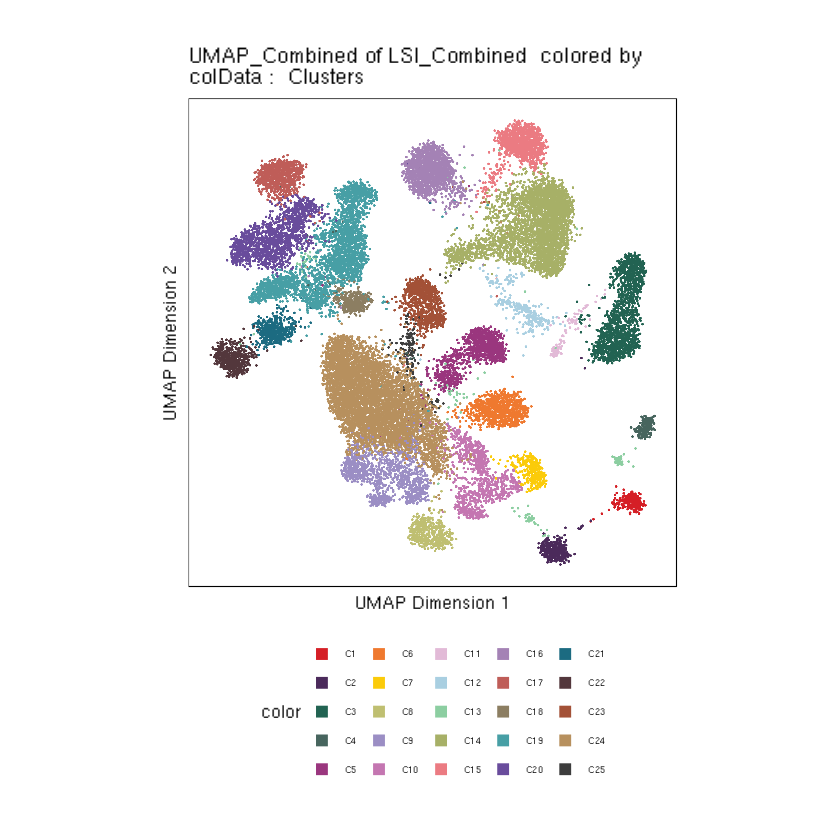

In [24]:
plotEmbedding(proj_all, name = "Clusters", embedding = "UMAP_Combined", size = 0.3, labelAsFactors=F, labelMeans=F)

In [25]:
#Save ArchR Project
saveArchRProject(ArchRProj = proj_all, outputDirectory = "proj_all")

Copying ArchRProject to new outputDirectory : /oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome/proj_all

Copying Arrow Files...

Copying Arrow Files (1 of 5)

Copying Arrow Files (2 of 5)

Copying Arrow Files (3 of 5)

Copying Arrow Files (4 of 5)

Copying Arrow Files (5 of 5)

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Copying Other Files (1 of 3): Embeddings

Copying Other Files (2 of 3): LSI_ATAC

Copying Other Files (3 of 3): LSI_RNA

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \

class: ArchRProject 
outputDirectory: /oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome/proj_all 
samples(5): sample2_6_3 sample1_5_25 sample2_12_22 sample1_6_3
  sample1_12_22
sampleColData names(1): ArrowFiles
cellColData names(19): Sample TSSEnrichment ... Stage Clusters
numberOfCells(1): 27424
medianTSS(1): 14.95
medianFrags(1): 9276.5

## Remove doublet clusters

In [2]:
#Load ArchR Project
proj_all <- loadArchRProject('proj_all')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [3]:
seGEX <- getMarkerFeatures(ArchRProj = proj_all, useMatrix = "GeneExpressionMatrix")

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-7ee24478853a-Date-2024-05-29_Time-15-07-40.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2024-05-29 15:07:52 : Matching Known Biases, 0.193 mins elapsed.

###########
2024-05-29 15:09:02 : Completed Pairwise Tests, 1.359 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-7ee24478853a-Date-2024-05-29_Time-15-07-40.log



In [4]:
subsetSE_GEX <- seGEX[which(rowData(seGEX)$name %in% c(
    "Slc17a6", #Excitatory
    "Slc32a1", #Inhibitory
    "Aqp4", "Slc1a2", #Astrocyte
    "Csf1r", #Microglia
    "Mog", "Sox10", #Oligodendrocyte
    "Slc5a7", #Cholinergic
    "Cfap43", #Ependymal
    "Pdgfra", #OPC
    "Atf3"  #Degenerating
  )),]

In [5]:
GEX_matrix <- plotMarkerHeatmap(seMarker = subsetSE_GEX, log2Norm = FALSE, scaleRows = FALSE, limits = c(-Inf, Inf), returnMatrix = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-7ee250224be8-Date-2024-05-29_Time-15-09-03.log
If there is an issue, please report to github with logFile!

Identified 11 markers!



 [1] "Aqp4"    "Slc1a2"  "Atf3"    "Sox10"   "Mog"     "Slc5a7"  "Csf1r"  
 [8] "Cfap43"  "Slc32a1" "Pdgfra"  "Slc17a6"


ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-7ee250224be8-Date-2024-05-29_Time-15-09-03.log



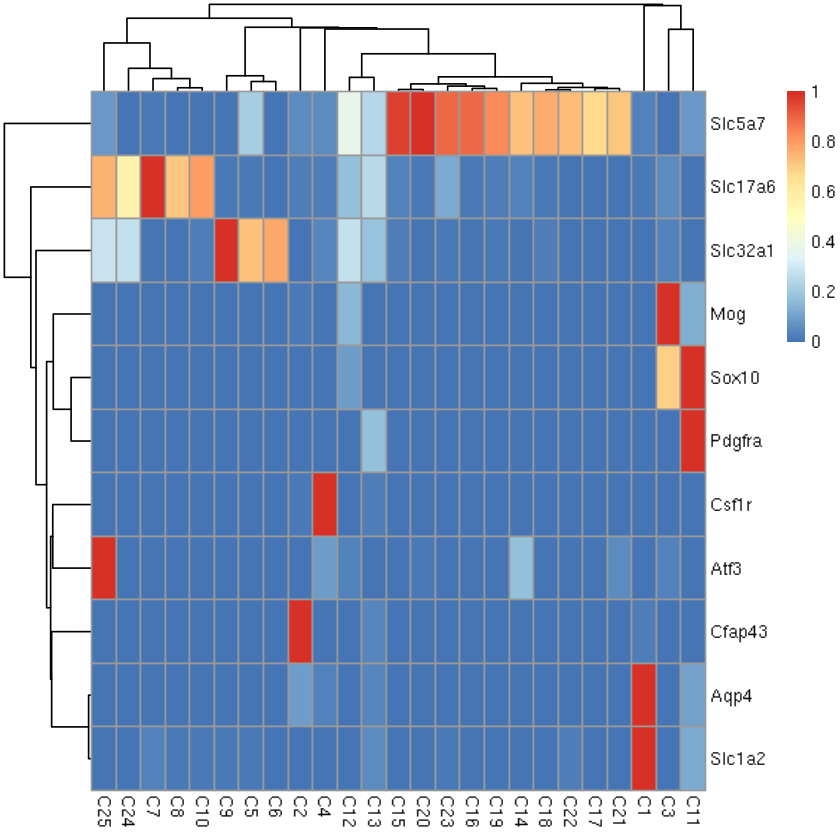

In [6]:
heatmap.avgexp <- (GEX_matrix - rowMins(GEX_matrix))/(rowMaxs(GEX_matrix) - rowMins(GEX_matrix))
pheatmap(heatmap.avgexp)

In [7]:
#Clusters 12 and 13 are doublet clusters
proj_all_dr <- proj_all[proj_all$Clusters %ni% c("C12", "C13")]

In [8]:
#Relabel clusters
newLabels <- c('C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 
               'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'C22', 'C23')

oldLabels <- c('C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C14', 'C15', 
               'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'C22', 'C23', 'C24', 'C25')

proj_all_dr$Clusters <- mapLabels(proj_all_dr$Clusters, newLabels = newLabels, oldLabels = oldLabels)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-7ee23c084a6b-Date-2024-05-29_Time-15-09-04.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 
Length of unique values greater than palette, interpolating..



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-7ee23c084a6b-Date-2024-05-29_Time-15-09-04.log



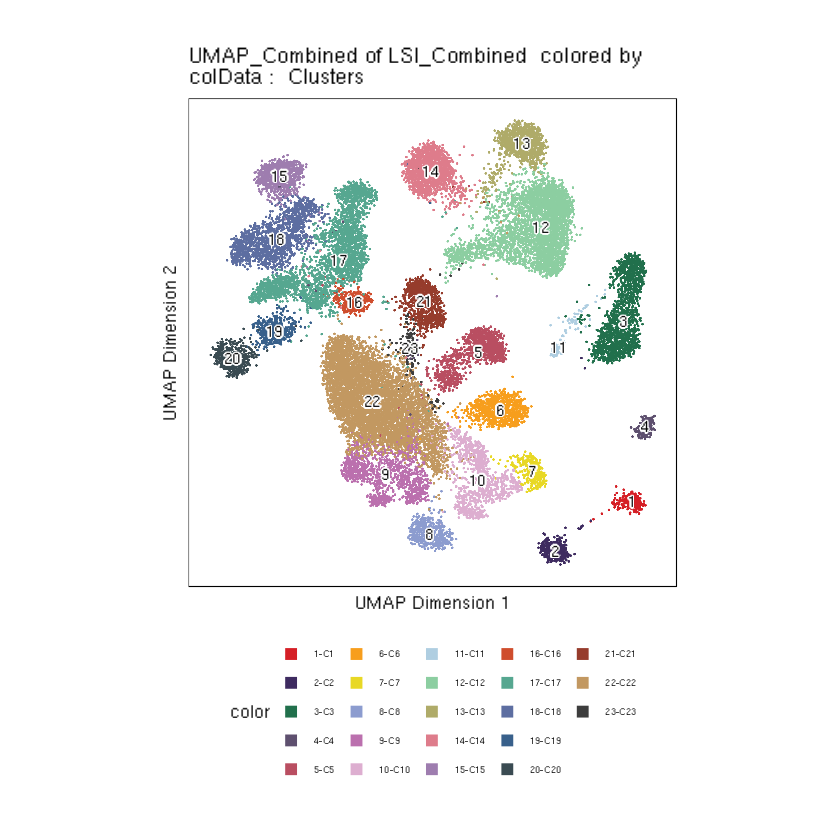

In [9]:
all_UMAP <- plotEmbedding(proj_all_dr, name = "Clusters", embedding = "UMAP_Combined", size = 0.3, labelAsFactors=T, labelMeans=T)
all_UMAP

In [10]:
plotPDF(all_UMAP, name = "all_UMAP", width = 4.5, height = 4.5, addDOC = FALSE)

Plotting Ggplot!



## Marker gene heatmap

In [22]:
#Load ArchR Project
proj_all_dr <- loadArchRProject('proj_all_dr')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [23]:
seGEX <- getMarkerFeatures(ArchRProj = proj_all_dr, useMatrix = "GeneExpressionMatrix")

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-34757f2372ce-Date-2025-08-12_Time-21-14-53.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2025-08-12 21:14:55 : Matching Known Biases, 0.003 mins elapsed.

###########
2025-08-12 21:16:20 : Completed Pairwise Tests, 1.432 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-34757f2372ce-Date-2025-08-12_Time-21-14-53.log



In [24]:
subsetSE_GEX <- seGEX[which(rowData(seGEX)$name %in% c(
    "Slc17a6", #Excitatory
    "Slc32a1", #Inhibitory
    "Aqp4", "Slc1a2", #Astrocyte
    "Csf1r", #Microglia
    "Mog", "Sox10", #Oligodendrocyte
    "Slc5a7", #Cholinergic
    "Cfap43", #Ependymal
    "Pdgfra", #OPC
    "Atf3"  #Degenerating
  )),]

In [25]:
GEX_matrix <- plotMarkerHeatmap(seMarker = subsetSE_GEX, log2Norm = FALSE, scaleRows = FALSE, limits = c(-Inf, Inf), returnMatrix = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-347577e6d4bf-Date-2025-08-12_Time-21-16-20.log
If there is an issue, please report to github with logFile!

Identified 11 markers!



 [1] "Aqp4"    "Slc1a2"  "Atf3"    "Sox10"   "Mog"     "Slc5a7"  "Csf1r"  
 [8] "Cfap43"  "Slc32a1" "Pdgfra"  "Slc17a6"


ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-347577e6d4bf-Date-2025-08-12_Time-21-16-20.log



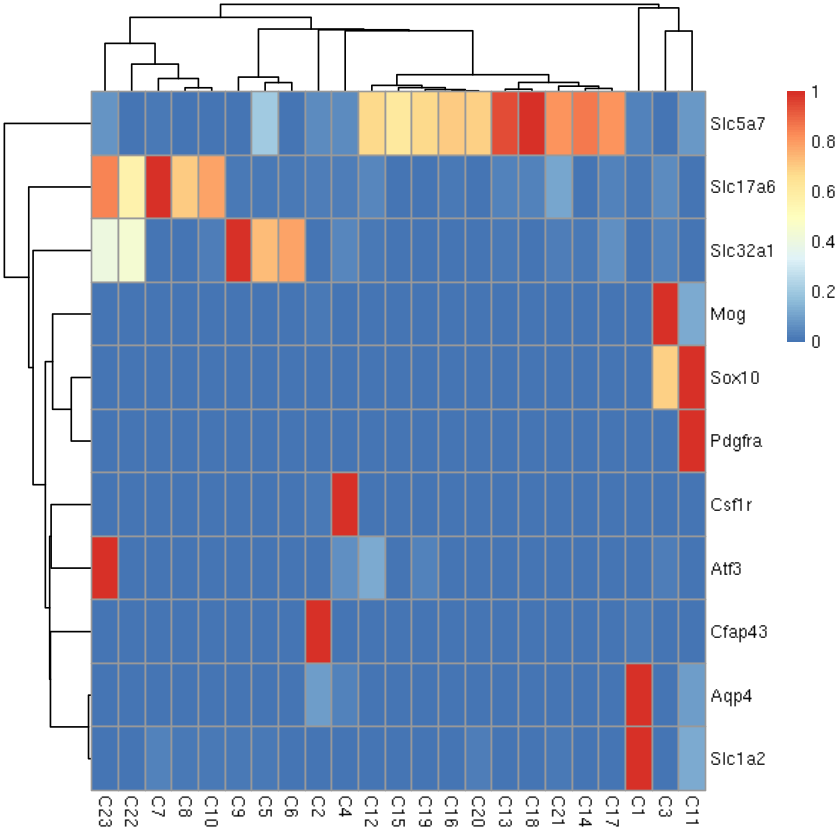

In [26]:
heatmap.avgexp <- (GEX_matrix - rowMins(GEX_matrix))/(rowMaxs(GEX_matrix) - rowMins(GEX_matrix))
pheatmap(heatmap.avgexp)

In [27]:
row_order <- c('C18','C13','C14','C21','C17','C20','C16','C19','C15','C12','C5','C6','C9','C22','C8','C7','C10','C23','C1','C3','C11','C4','C2')
heatmap.avgexp <- heatmap.avgexp[,row_order]

col_order <- c('Slc5a7','Slc32a1','Slc17a6','Atf3','Aqp4','Slc1a2','Mog','Sox10','Pdgfra','Csf1r','Cfap43')
heatmap.avgexp <- heatmap.avgexp[col_order,]

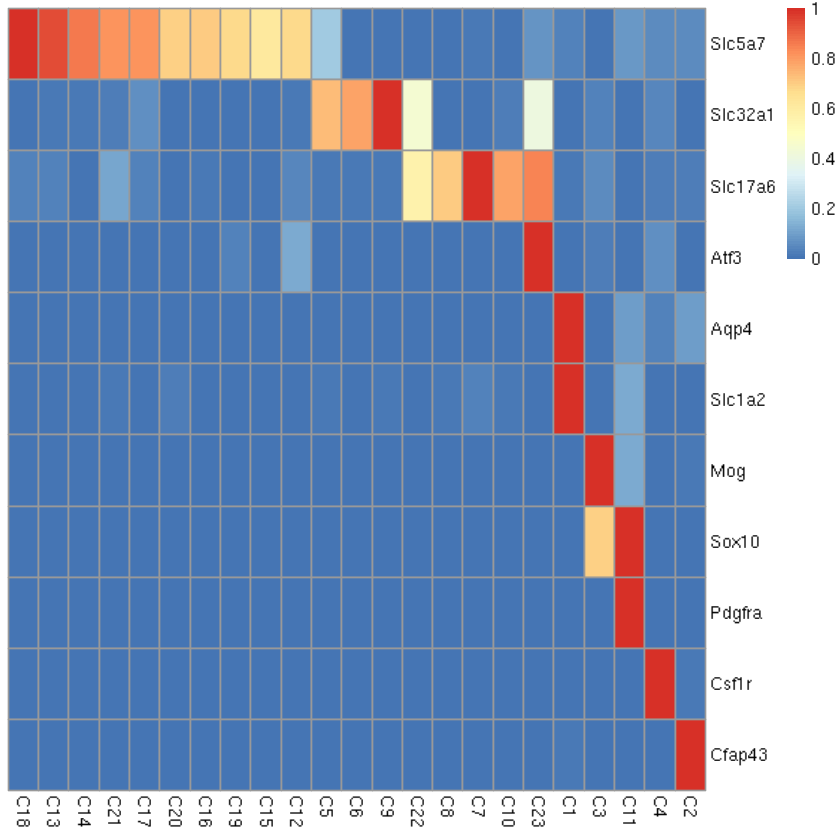

In [28]:
pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE)

In [29]:
pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE, filename = 'Figures/multiome_all_heatmap_final.pdf', width = 4.275, height = 2.15, fontsize = 7)

## Add cell class annotations

In [2]:
#Load ArchR Project
proj_all_dr <- loadArchRProject('proj_all_dr')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [3]:
#Add cell class annotations
newLabels <- c('Astrocytes', 'Ependymal Cells', 'Oligodendrocytes', 'Microglia/Macrophages', 'Cholinergic Neurons', 
               'Non-Cholinergic Interneurons', 'Non-Cholinergic Interneurons', 'Non-Cholinergic Interneurons', 
               'Non-Cholinergic Interneurons', 'Non-Cholinergic Interneurons', 'OPCs', 'Cholinergic Neurons', 
               'Cholinergic Neurons', 'Cholinergic Neurons', 'Cholinergic Neurons', 'Cholinergic Neurons', 
               'Cholinergic Neurons', 'Cholinergic Neurons', 'Cholinergic Neurons', 'Cholinergic Neurons', 
               'Cholinergic Neurons', 'Non-Cholinergic Interneurons', 'Disease-Associated Interneurons')

oldLabels <- c('C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 
               'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'C22', 'C23')

proj_all_dr$cell_class <- mapLabels(proj_all_dr$Clusters, newLabels = newLabels, oldLabels = oldLabels)

In [22]:
#Add cell class UMAP labels
newLabels <- c('Astrocytes       ', 'Ependymal Cells', 'Oligos', 'Microglia/Macro.                  ', 'Cholinergic Neurons', 
               'Non-Cholinergic Intern.', 'Non-Cholinergic Intern.', 'Non-Cholinergic Intern.', 
               'Non-Cholinergic Intern.', 'Non-Cholinergic Intern.', 'OPCs', 'Cholinergic Neurons', 
               'Cholinergic Neurons', 'Cholinergic Neurons', 'Cholinergic Neurons', 'Cholinergic Neurons', 
               'Cholinergic Neurons', 'Cholinergic Neurons', 'Cholinergic Neurons', 'Cholinergic Neurons', 
               'Cholinergic Neurons', 'Non-Cholinergic Intern.', 'DAI')

oldLabels <- c('C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 
               'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'C22', 'C23')

proj_all_dr$cell_class_UMAP_labels <- mapLabels(proj_all_dr$Clusters, newLabels = newLabels, oldLabels = oldLabels)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-73872d61b2bf-Date-2025-06-03_Time-13-23-50.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-73872d61b2bf-Date-2025-06-03_Time-13-23-50.log



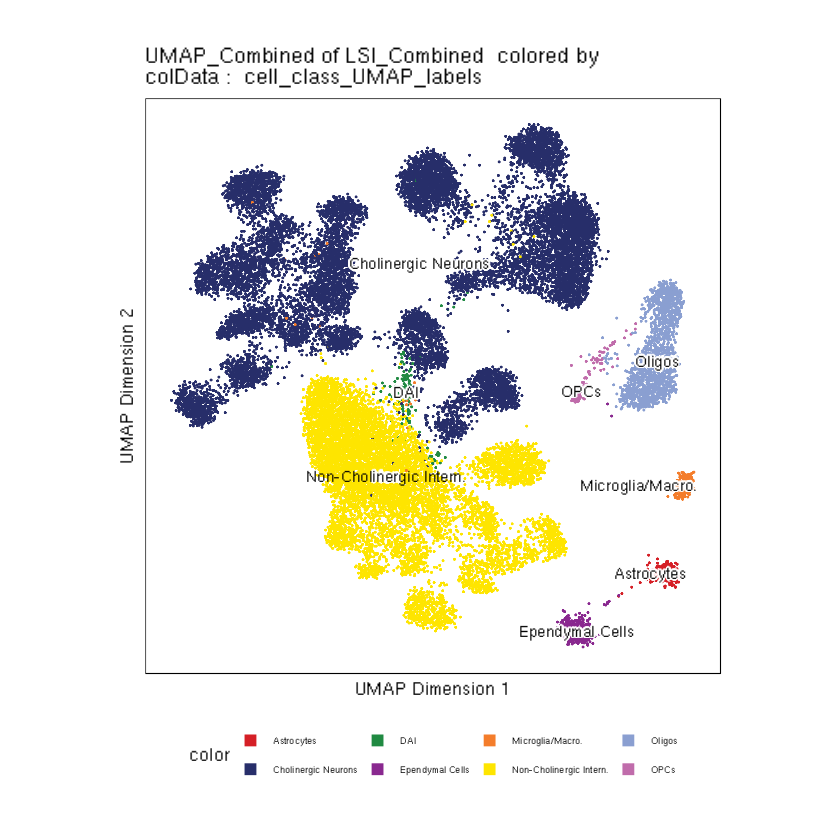

In [23]:
all_UMAP_annotated <- plotEmbedding(proj_all_dr, name = "cell_class_UMAP_labels", embedding = "UMAP_Combined", size = 0.3, labelAsFactors=F, labelMeans=T)
all_UMAP_annotated

In [24]:
plotPDF(all_UMAP_annotated, name = "all_UMAP_annotated", width = 4.5, height = 4.5, addDOC = FALSE)

Plotting Ggplot!



In [25]:
#Save ArchR Project
saveArchRProject(ArchRProj = proj_all_dr, outputDirectory = "proj_all_dr")

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome/proj_all_dr 
samples(5): sample2_6_3 sample1_5_25 sample2_12_22 sample1_6_3
  sample1_12_22
sampleColData names(1): ArrowFiles
cellColData names(23): Sample TSSEnrichment ... ReadsInPeaks FRIP
numberOfCells(1): 26965
medianTSS(1): 14.885
medianFrags(1): 9220

## Subset cholinergic neurons

In [2]:
#Load ArchR Project
proj_all_dr <- loadArchRProject('proj_all_dr')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [3]:
proj_cholinergic <- proj_all_dr[proj_all_dr$cell_class == 'Cholinergic Neurons']

In [4]:
#LSI-ATAC
proj_cholinergic <- addIterativeLSI(
    ArchRProj = proj_cholinergic, 
    clusterParams = list(
      resolution = 0.2, 
      sampleCells = 10000,
      n.start = 10
    ),
    saveIterations = FALSE,
    useMatrix = "TileMatrix", 
    depthCol = "nFrags",
    name = "LSI_ATAC",
    force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-2986381e1603-Date-2024-04-15_Time-11-43-27.log
If there is an issue, please report to github with logFile!

2024-04-15 11:43:56 : Computing Total Across All Features, 0.292 mins elapsed.

2024-04-15 11:44:02 : Computing Top Features, 0.379 mins elapsed.

###########
2024-04-15 11:44:02 : Running LSI (1 of 2) on Top Features, 0.394 mins elapsed.
###########

2024-04-15 11:44:03 : Sampling Cells (N = 10002) for Estimated LSI, 0.395 mins elapsed.

2024-04-15 11:44:03 : Creating Sampled Partial Matrix, 0.395 mins elapsed.

2024-04-15 11:44:13 : Computing Estimated LSI (projectAll = FALSE), 0.57 mins elapsed.

2024-04-15 11:44:57 : Identifying Clusters, 1.3 mins elapsed.

2024-04-15 11:45:30 : Identified 4 Clusters, 1.858 mins elapsed.

2024-04-15 11:45:30 : Creating Cluster Matrix on the total Group Features, 1.859 mins elapsed.

2024-04-15 11:45:40 : Computing Variable Features, 2.02 mins elapsed.

###########
2024-04-

In [5]:
#LSI-RNA
proj_cholinergic <- addIterativeLSI(
    ArchRProj = proj_cholinergic, 
    clusterParams = list(
      resolution = 0.2, 
      sampleCells = 10000,
      n.start = 10
    ),
    saveIterations = FALSE,
    useMatrix = "GeneExpressionMatrix", 
    depthCol = "Gex_nUMI",
    varFeatures = 2500,
    firstSelection = "variable",
    binarize = FALSE,
    name = "LSI_RNA",
    force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-298650ed625a-Date-2024-04-15_Time-11-46-34.log
If there is an issue, please report to github with logFile!

2024-04-15 11:46:35 : Computing Variability Across All Features, 0.003 mins elapsed.

2024-04-15 11:46:37 : Computing Variable Features, 0.037 mins elapsed.

###########
2024-04-15 11:46:38 : Running LSI (1 of 2) on Top Features, 0.049 mins elapsed.
###########

2024-04-15 11:46:38 : Sampling Cells (N = 10002) for Estimated LSI, 0.05 mins elapsed.

2024-04-15 11:46:38 : Creating Sampled Partial Matrix, 0.05 mins elapsed.

2024-04-15 11:46:42 : Computing Estimated LSI (projectAll = FALSE), 0.12 mins elapsed.

2024-04-15 11:46:50 : Identifying Clusters, 0.252 mins elapsed.

2024-04-15 11:47:02 : Identified 14 Clusters, 0.453 mins elapsed.

2024-04-15 11:47:02 : Creating Cluster Matrix on the total Group Features, 0.453 mins elapsed.

2024-04-15 11:47:08 : Computing Variable Features, 0.553 mins elapsed.

#######

In [6]:
#Combined Dims
proj_cholinergic <- addCombinedDims(proj_cholinergic, reducedDims = c("LSI_ATAC", "LSI_RNA"), name =  "LSI_Combined")

In [7]:
#UMAPs
proj_cholinergic <- addUMAP(proj_cholinergic, reducedDims = "LSI_ATAC", name = "UMAP_ATAC", minDist = 0.5, force = TRUE)
proj_cholinergic <- addUMAP(proj_cholinergic, reducedDims = "LSI_RNA", name = "UMAP_RNA", minDist = 0.5, force = TRUE)
proj_cholinergic <- addUMAP(proj_cholinergic, reducedDims = "LSI_Combined", name = "UMAP_Combined", minDist = 0.5, force = TRUE)

11:47:24 UMAP embedding parameters a = 0.583 b = 1.334

11:47:24 Read 14639 rows and found 30 numeric columns

11:47:24 Using Annoy for neighbor search, n_neighbors = 40

11:47:24 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:47:25 Writing NN index file to temp file /tmp/Rtmp7Yc3Y4/file29869175944

11:47:25 Searching Annoy index using 16 threads, search_k = 4000

11:47:26 Annoy recall = 100%

11:47:27 Commencing smooth kNN distance calibration using 16 threads
 with target n_neighbors = 40

11:47:27 Initializing from normalized Laplacian + noise (using irlba)

11:47:28 Commencing optimization for 200 epochs, with 904112 positive edges

11:47:46 Optimization finished

11:47:46 Creating temp model dir /tmp/Rtmp7Yc3Y4/dir298676322d22

11:47:46 Creating dir /tmp/Rtmp7

In [8]:
#Add Clusters
proj_cholinergic <- addClusters(proj_cholinergic, reducedDims = "LSI_Combined", name = "Clusters", resolution = 0.5, force = TRUE)

ArchR logging to : ArchRLogs/ArchR-addClusters-2986387d1073-Date-2024-04-15_Time-11-48-37.log
If there is an issue, please report to github with logFile!

Overriding previous entry for Clusters

2024-04-15 11:48:38 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.001 mins elapsed.

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 14639
Number of edges: 704605

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9421
Number of communities: 20
Elapsed time: 1 seconds


2024-04-15 11:49:01 : Testing Outlier Clusters, 0.383 mins elapsed.

2024-04-15 11:49:01 : Assigning Cluster Names to 20 Clusters, 0.383 mins elapsed.

2024-04-15 11:49:01 : Finished addClusters, 0.385 mins elapsed.



ArchR logging to : ArchRLogs/ArchR-plotEmbedding-2986499298d8-Date-2024-04-15_Time-11-49-01.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-2986499298d8-Date-2024-04-15_Time-11-49-01.log



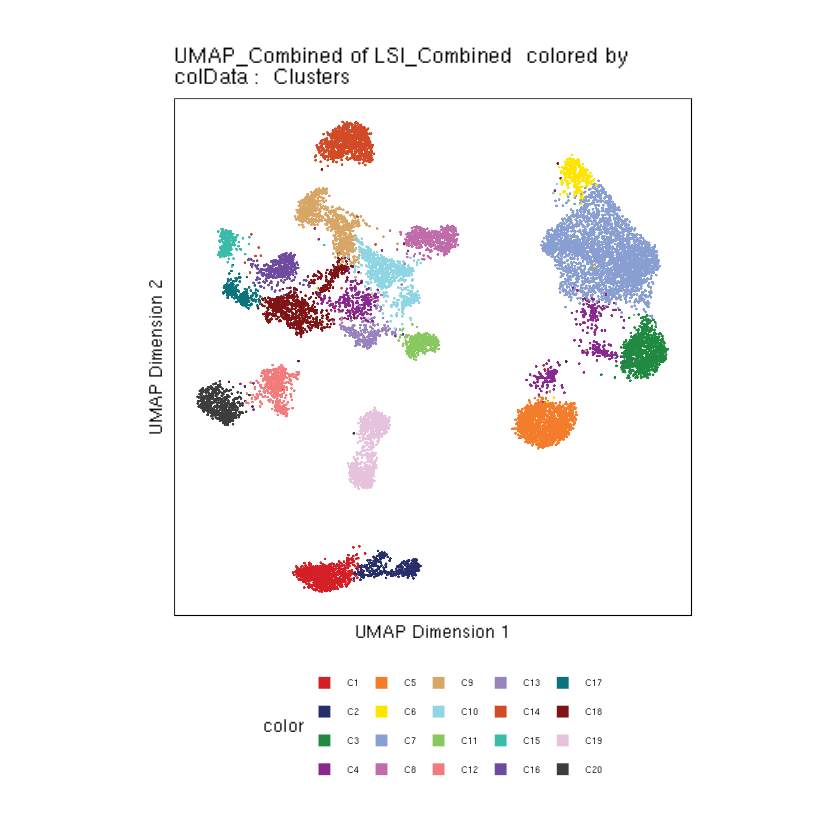

In [9]:
plotEmbedding(proj_cholinergic, name = "Clusters", embedding = "UMAP_Combined", size = 0.3, labelAsFactors=F, labelMeans=F)

In [10]:
#Save ArchR Project
saveArchRProject(ArchRProj = proj_cholinergic, outputDirectory = "proj_cholinergic")

Copying ArchRProject to new outputDirectory : /oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome/proj_cholinergic

Copying Arrow Files...

Copying Arrow Files (1 of 5)

Copying Arrow Files (2 of 5)

Copying Arrow Files (3 of 5)

Copying Arrow Files (4 of 5)

Copying Arrow Files (5 of 5)

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Copying Other Files (1 of 4): Embeddings

Copying Other Files (2 of 4): LSI_ATAC

Copying Other Files (3 of 4): LSI_RNA

Copying Other Files (4 of 4): Plots

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \              

class: ArchRProject 
outputDirectory: /oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome/proj_cholinergic 
samples(5): sample2_6_3 sample1_5_25 sample2_12_22 sample1_6_3
  sample1_12_22
sampleColData names(1): ArrowFiles
cellColData names(21): Sample TSSEnrichment ... cell_class
  cell_class_UMAP_labels
numberOfCells(1): 14639
medianTSS(1): 12.941
medianFrags(1): 11936

## Remove doublet clusters

In [2]:
#Load ArchR Project
proj_cholinergic <- loadArchRProject('proj_cholinergic')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [3]:
seGEX_cholinergic <- getMarkerFeatures(ArchRProj = proj_cholinergic, useMatrix = "GeneExpressionMatrix")

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-6f7d7e30fbe2-Date-2024-04-15_Time-15-40-14.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2024-04-15 15:40:21 : Matching Known Biases, 0.102 mins elapsed.

###########
2024-04-15 15:41:36 : Completed Pairwise Tests, 1.361 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-6f7d7e30fbe2-Date-2024-04-15_Time-15-40-14.log



In [4]:
subsetSE_GEX_cholinergic <- seGEX_cholinergic[which(rowData(seGEX_cholinergic)$name %in% c(
    "Bcl6", #Skeletal
    "Fbn2", "Zeb2", #Visceral
    "Rxfp1", #Sacral visceral
    "Pitx2", #Pitx2+
    "Gad1" #Inhibitory
  )),]

In [5]:
GEX_matrix_cholinergic <- plotMarkerHeatmap(seMarker = subsetSE_GEX_cholinergic, log2Norm = FALSE, scaleRows = FALSE, limits = c(-Inf, Inf), returnMatrix = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-6f7d4eb2b23c-Date-2024-04-15_Time-15-41-36.log
If there is an issue, please report to github with logFile!

Identified 6 markers!



[1] "Gad1"  "Bcl6"  "Fbn2"  "Zeb2"  "Rxfp1" "Pitx2"


ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-6f7d4eb2b23c-Date-2024-04-15_Time-15-41-36.log



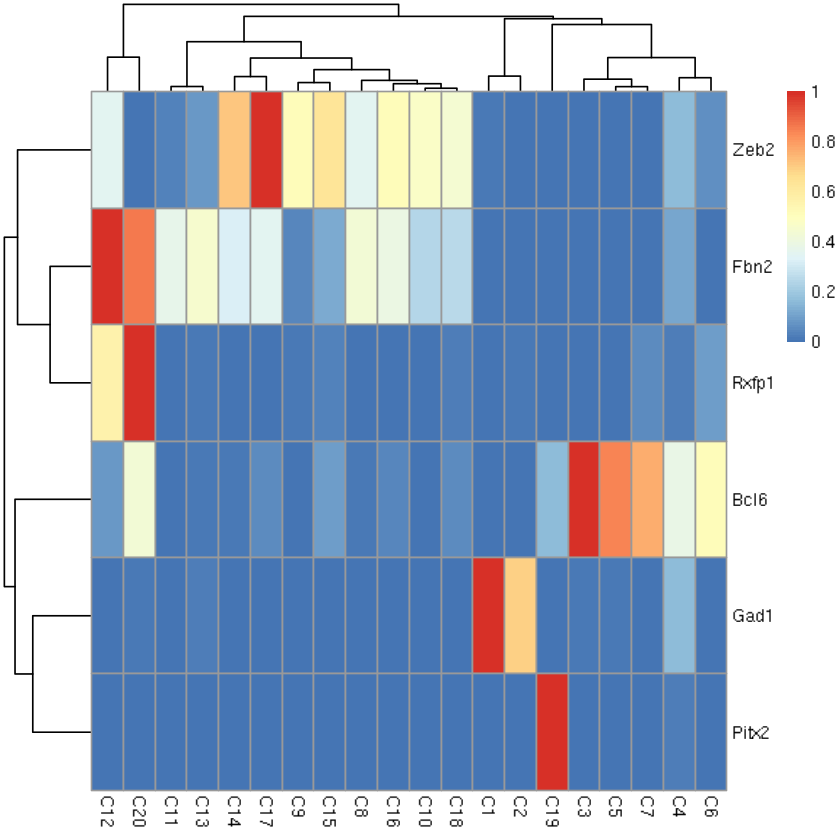

In [6]:
heatmap.avgexp_cholinergic <- (GEX_matrix_cholinergic - rowMins(GEX_matrix_cholinergic))/(rowMaxs(GEX_matrix_cholinergic) - rowMins(GEX_matrix_cholinergic))
pheatmap(heatmap.avgexp_cholinergic)

In [7]:
#Cluster 4 is a doublet cluster
proj_cholinergic_dr <- proj_cholinergic[proj_cholinergic$Clusters %ni% c("C4")]

In [8]:
#Recluster using only ATAC data
proj_cholinergic_dr <- addClusters(proj_cholinergic_dr, reducedDims = "LSI_ATAC", name = "Clusters", resolution = 0.2, force = TRUE)

ArchR logging to : ArchRLogs/ArchR-addClusters-6f7d49748910-Date-2024-04-15_Time-15-41-38.log
If there is an issue, please report to github with logFile!

Overriding previous entry for Clusters

2024-04-15 15:41:51 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.217 mins elapsed.

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 14066
Number of edges: 592137

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9510
Number of communities: 7
Elapsed time: 1 seconds


2024-04-15 15:42:08 : Testing Outlier Clusters, 0.51 mins elapsed.

2024-04-15 15:42:08 : Assigning Cluster Names to 7 Clusters, 0.511 mins elapsed.

2024-04-15 15:42:09 : Finished addClusters, 0.515 mins elapsed.



ArchR logging to : ArchRLogs/ArchR-plotEmbedding-6f7d21c50dc1-Date-2024-04-15_Time-15-42-09.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-6f7d21c50dc1-Date-2024-04-15_Time-15-42-09.log



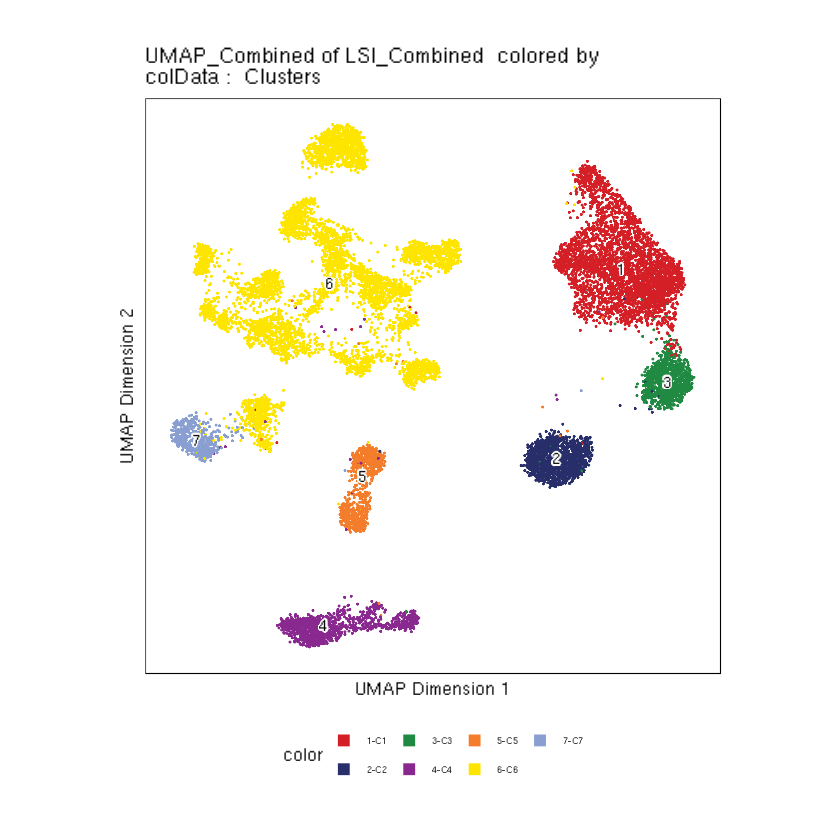

In [9]:
cholinergic_UMAP <- plotEmbedding(proj_cholinergic_dr, name = "Clusters", embedding = "UMAP_Combined", size = 0.3, labelAsFactors=T, labelMeans=T)
cholinergic_UMAP

In [10]:
plotPDF(cholinergic_UMAP, name = "cholinergic_UMAP", width = 4.5, height = 4.5, addDOC = FALSE)

Plotting Ggplot!



## Marker gene heatmap

In [30]:
#Load ArchR Project
proj_cholinergic_dr <- loadArchRProject('proj_cholinergic_dr')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [31]:
seGEX_cholinergic <- getMarkerFeatures(ArchRProj = proj_cholinergic_dr, useMatrix = "GeneExpressionMatrix")

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-34752f3075ab-Date-2025-08-12_Time-21-19-16.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2025-08-12 21:19:17 : Matching Known Biases, 0.003 mins elapsed.

###########
2025-08-12 21:19:49 : Completed Pairwise Tests, 0.526 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-34752f3075ab-Date-2025-08-12_Time-21-19-16.log



In [32]:
subsetSE_GEX_cholinergic <- seGEX_cholinergic[which(rowData(seGEX_cholinergic)$name %in% c(
    "Bcl6", #Skeletal
    "Fbn2", "Zeb2", #Visceral
    "Rxfp1", #Sacral visceral
    "Pitx2", #Pitx2+
    "Gad1", #Inhibitory
    "Mrvi1", "Stk32a", #Alpha
    "Npas1", #Pan-gamma
    "Plch1", #Gamma*
    "Pard3b" #Gamma
  )),]

In [33]:
GEX_matrix_cholinergic <- plotMarkerHeatmap(seMarker = subsetSE_GEX_cholinergic, log2Norm = FALSE, scaleRows = FALSE, limits = c(-Inf, Inf), returnMatrix = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-3475449663b9-Date-2025-08-12_Time-21-19-49.log
If there is an issue, please report to github with logFile!

Identified 11 markers!



 [1] "Mrvi1"  "Stk32a" "Plch1"  "Bcl6"   "Pard3b" "Fbn2"   "Zeb2"   "Gad1"  
 [9] "Rxfp1"  "Pitx2"  "Npas1" 


ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-3475449663b9-Date-2025-08-12_Time-21-19-49.log



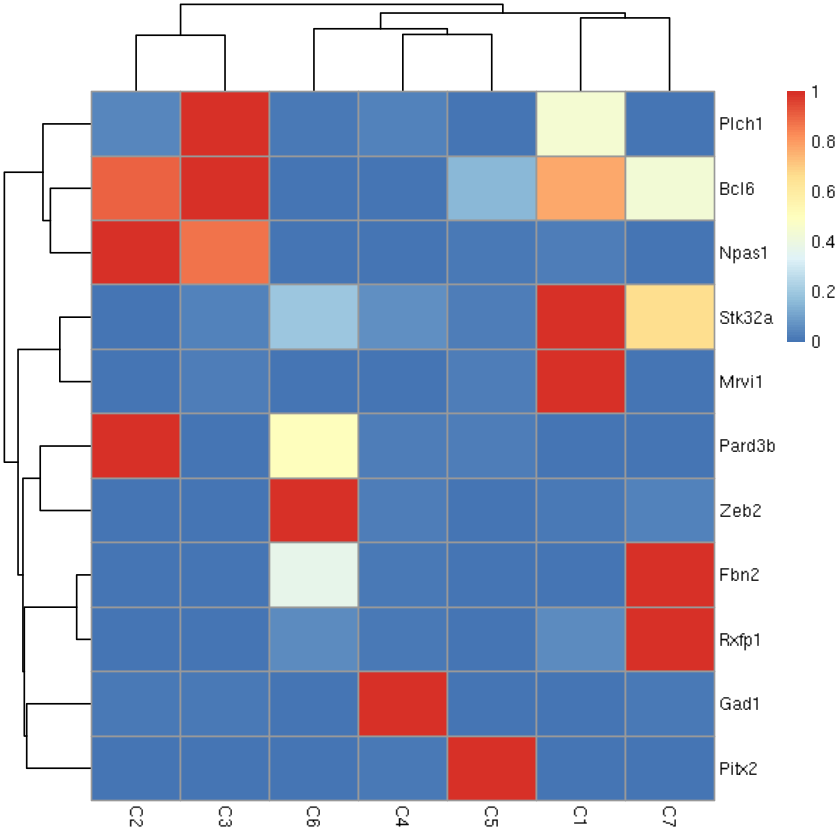

In [34]:
heatmap.avgexp_cholinergic <- (GEX_matrix_cholinergic - rowMins(GEX_matrix_cholinergic))/(rowMaxs(GEX_matrix_cholinergic) - rowMins(GEX_matrix_cholinergic))
pheatmap(heatmap.avgexp_cholinergic)

In [35]:
col_order <- c('C1','C3','C2','C5','C4','C6','C7')
heatmap.avgexp_cholinergic <- heatmap.avgexp_cholinergic[,col_order]

row_order <- c('Bcl6','Stk32a','Mrvi1','Npas1','Plch1','Pard3b','Pitx2','Gad1','Zeb2','Fbn2','Rxfp1')
heatmap.avgexp_cholinergic <- heatmap.avgexp_cholinergic[row_order,]

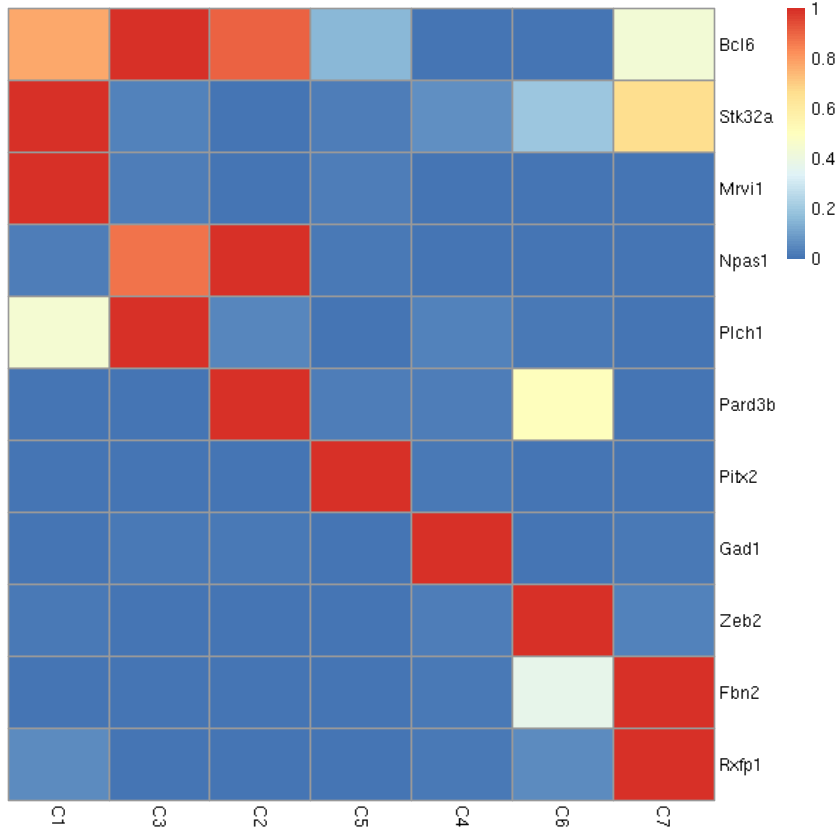

In [36]:
pheatmap(heatmap.avgexp_cholinergic, cluster_rows = FALSE, cluster_cols = FALSE)

In [42]:
pheatmap(heatmap.avgexp_cholinergic, cluster_rows = FALSE, cluster_cols = FALSE, legend = FALSE, filename = 'Figures/multiome_cholinergic_heatmap_final.pdf', width = 1.75, height = 2.15, fontsize = 7)

## Add cholinergic type annotations

In [25]:
#Add cholinergic type annotations
newLabels <- c('Alpha MNs', 'Gamma MNs', 'Gamma* MNs', 'Gad1+ Cholinergic Interneurons',  
               'Pitx2+ Cholinergic Interneurons', 'Visceral MNs', 'Visceral MNs')

oldLabels <- c('C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7')

proj_cholinergic_dr$cholinergic_type <- mapLabels(proj_cholinergic_dr$Clusters, newLabels = newLabels, oldLabels = oldLabels)

In [26]:
#Add cholinergic type UMAP labels
newLabels <- c('Alpha MNs', 'Gamma MNs', 'Gamma* MNs             ', '               Gad1+ Cholinergic Interneurons',  
               '
     Pitx2+ Cholinergic Interneurons', 'Visceral MNs', 'Visceral MNs')

oldLabels <- c('C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7')

proj_cholinergic_dr$cholinergic_type_UMAP_labels <- mapLabels(proj_cholinergic_dr$Clusters, newLabels = newLabels, oldLabels = oldLabels)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-6f7d7eb96f92-Date-2024-04-15_Time-15-42-47.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-6f7d7eb96f92-Date-2024-04-15_Time-15-42-47.log



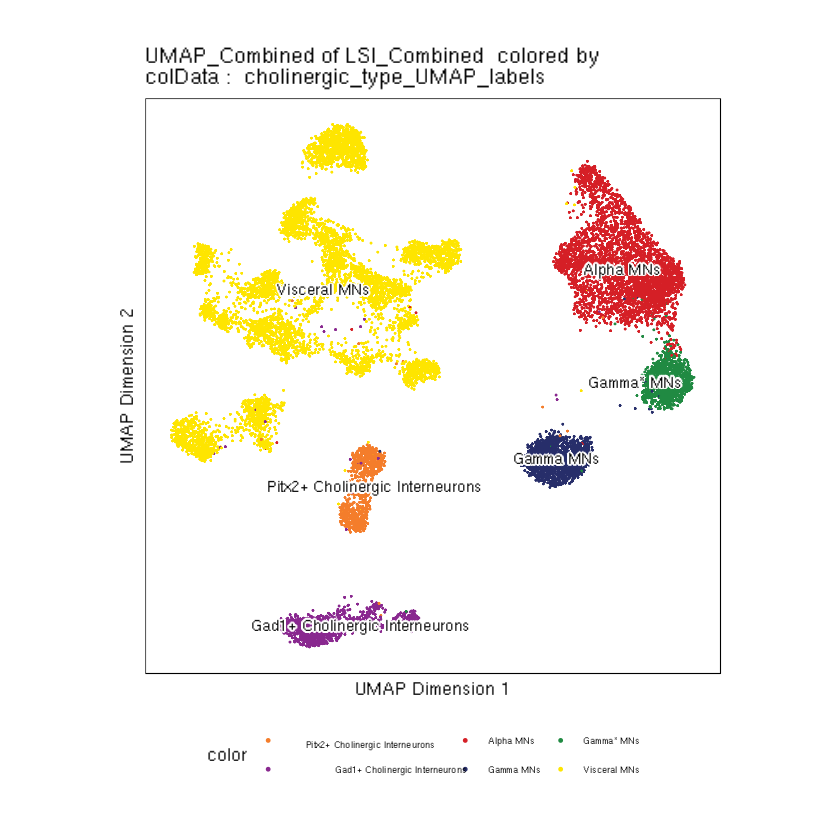

In [27]:
cholinergic_UMAP_annotated <- plotEmbedding(proj_cholinergic_dr, name = "cholinergic_type_UMAP_labels", embedding = "UMAP_Combined", pal = c('#F47D2B','#89288F','#D51F26','#272E6A','#208A42','#FEE500'), size = 0.3, labelAsFactors=F, labelMeans=T)
cholinergic_UMAP_annotated

In [28]:
plotPDF(cholinergic_UMAP_annotated, name = "cholinergic_UMAP_annotated", width = 4.5, height = 4.5, addDOC = FALSE)

Plotting Ggplot!



In [29]:
#Save ArchR Project
saveArchRProject(ArchRProj = proj_cholinergic_dr, outputDirectory = "proj_cholinergic_dr")

Copying ArchRProject to new outputDirectory : /oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome/proj_cholinergic_dr

Copying Arrow Files...

Copying Arrow Files (1 of 5)

Copying Arrow Files (2 of 5)

Copying Arrow Files (3 of 5)

Copying Arrow Files (4 of 5)

Copying Arrow Files (5 of 5)

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Copying Other Files (1 of 4): Embeddings

Copying Other Files (2 of 4): LSI_ATAC

Copying Other Files (3 of 4): LSI_RNA

Copying Other Files (4 of 4): Plots

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \           

class: ArchRProject 
outputDirectory: /oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome/proj_cholinergic_dr 
samples(5): sample2_6_3 sample1_5_25 sample2_12_22 sample1_6_3
  sample1_12_22
sampleColData names(1): ArrowFiles
cellColData names(23): Sample TSSEnrichment ... cholinergic_type
  cholinergic_type_UMAP_labels
numberOfCells(1): 14066
medianTSS(1): 12.906
medianFrags(1): 11656

## Subset alpha motor neurons

In [2]:
#Load ArchR Project
proj_cholinergic_dr <- loadArchRProject('proj_cholinergic_dr')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [3]:
proj_alpha <- proj_cholinergic_dr[proj_cholinergic_dr$cholinergic_type == 'Alpha MNs']

In [4]:
#LSI-ATAC
proj_alpha <- addIterativeLSI(
    ArchRProj = proj_alpha, 
    saveIterations = FALSE,
    useMatrix = "TileMatrix", 
    depthCol = "nFrags",
    name = "LSI_ATAC",
    force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-d279b64ca1-Date-2024-04-15_Time-17-01-34.log
If there is an issue, please report to github with logFile!

2024-04-15 17:01:50 : Computing Total Across All Features, 0.249 mins elapsed.

2024-04-15 17:01:54 : Computing Top Features, 0.318 mins elapsed.

###########
2024-04-15 17:01:55 : Running LSI (1 of 2) on Top Features, 0.333 mins elapsed.
###########

2024-04-15 17:01:55 : Creating Partial Matrix, 0.333 mins elapsed.

2024-04-15 17:02:00 : Computing LSI, 0.421 mins elapsed.

2024-04-15 17:02:21 : Identifying Clusters, 0.766 mins elapsed.

2024-04-15 17:02:30 : Identified 6 Clusters, 0.914 mins elapsed.

2024-04-15 17:02:30 : Creating Cluster Matrix on the total Group Features, 0.914 mins elapsed.

2024-04-15 17:02:39 : Computing Variable Features, 1.068 mins elapsed.

###########
2024-04-15 17:02:39 : Running LSI (2 of 2) on Variable Features, 1.07 mins elapsed.
###########

2024-04-15 17:02:39 : Creating Partia

In [5]:
#LSI-RNA
proj_alpha <- addIterativeLSI(
    ArchRProj = proj_alpha, 
    saveIterations = FALSE,
    useMatrix = "GeneExpressionMatrix", 
    depthCol = "Gex_nUMI",
    varFeatures = 2500,
    firstSelection = "variable",
    binarize = FALSE,
    name = "LSI_RNA",
    force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-d277db0fcd-Date-2024-04-15_Time-17-02-56.log
If there is an issue, please report to github with logFile!

2024-04-15 17:02:57 : Computing Variability Across All Features, 0.003 mins elapsed.

2024-04-15 17:02:58 : Computing Variable Features, 0.03 mins elapsed.

###########
2024-04-15 17:02:59 : Running LSI (1 of 2) on Top Features, 0.042 mins elapsed.
###########

2024-04-15 17:02:59 : Creating Partial Matrix, 0.042 mins elapsed.

2024-04-15 17:03:02 : Computing LSI, 0.086 mins elapsed.

2024-04-15 17:03:07 : Identifying Clusters, 0.175 mins elapsed.

2024-04-15 17:03:11 : Identified 6 Clusters, 0.245 mins elapsed.

2024-04-15 17:03:11 : Creating Cluster Matrix on the total Group Features, 0.245 mins elapsed.

2024-04-15 17:03:17 : Computing Variable Features, 0.334 mins elapsed.

###########
2024-04-15 17:03:17 : Running LSI (2 of 2) on Variable Features, 0.334 mins elapsed.
###########

2024-04-15 17:03:17 : Crea

In [6]:
#Combined Dims
proj_alpha <- addCombinedDims(proj_alpha, reducedDims = c("LSI_ATAC", "LSI_RNA"), name =  "LSI_Combined")

In [7]:
#UMAPs
proj_alpha <- addUMAP(proj_alpha, reducedDims = "LSI_ATAC", name = "UMAP_ATAC", minDist = 0.4, force = TRUE)
proj_alpha <- addUMAP(proj_alpha, reducedDims = "LSI_RNA", name = "UMAP_RNA", minDist = 0.4, force = TRUE)
proj_alpha <- addUMAP(proj_alpha, reducedDims = "LSI_Combined", name = "UMAP_Combined", minDist = 0.4, force = TRUE)

17:03:24 UMAP embedding parameters a = 0.7669 b = 1.223

17:03:24 Read 3433 rows and found 30 numeric columns

17:03:24 Using Annoy for neighbor search, n_neighbors = 40

17:03:24 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:03:24 Writing NN index file to temp file /tmp/RtmpzgaMfS/filed2779ab3de5

17:03:24 Searching Annoy index using 16 threads, search_k = 4000

17:03:25 Annoy recall = 100%

17:03:25 Commencing smooth kNN distance calibration using 16 threads
 with target n_neighbors = 40

17:03:26 Initializing from normalized Laplacian + noise (using irlba)

17:03:26 Commencing optimization for 500 epochs, with 237746 positive edges

17:03:37 Optimization finished

17:03:37 Creating temp model dir /tmp/RtmpzgaMfS/dird2718fcc9cd

17:03:37 Creating dir /tmp/Rtmpzg

In [8]:
#Add Clusters
proj_alpha <- addClusters(proj_alpha, reducedDims = "LSI_ATAC", name = "Clusters", resolution = 1.2, nOutlier = 10, force = TRUE)

ArchR logging to : ArchRLogs/ArchR-addClusters-d279351010-Date-2024-04-15_Time-17-04-05.log
If there is an issue, please report to github with logFile!

Overriding previous entry for Clusters

2024-04-15 17:04:05 : Running Seurats FindClusters (Stuart et al. Cell 2019), 0.001 mins elapsed.

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 3433
Number of edges: 315424

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.4637
Number of communities: 6
Elapsed time: 0 seconds


2024-04-15 17:04:11 : Testing Biased Clusters, 0.101 mins elapsed.

2024-04-15 17:04:11 : Testing Outlier Clusters, 0.101 mins elapsed.

2024-04-15 17:04:11 : Assigning Outlier Clusters (n = 1, nOutlier < 10 cells) to Neighbors, 0.101 mins elapsed.

2024-04-15 17:04:11 : Assigning Cluster Names to 5 Clusters, 0.102 mins elapsed.

2024-04-15 17:04:11 : Finished addClusters, 0.103 mins elapsed.



ArchR logging to : ArchRLogs/ArchR-plotEmbedding-d2763ea35c7-Date-2024-04-15_Time-17-04-11.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-d2763ea35c7-Date-2024-04-15_Time-17-04-11.log



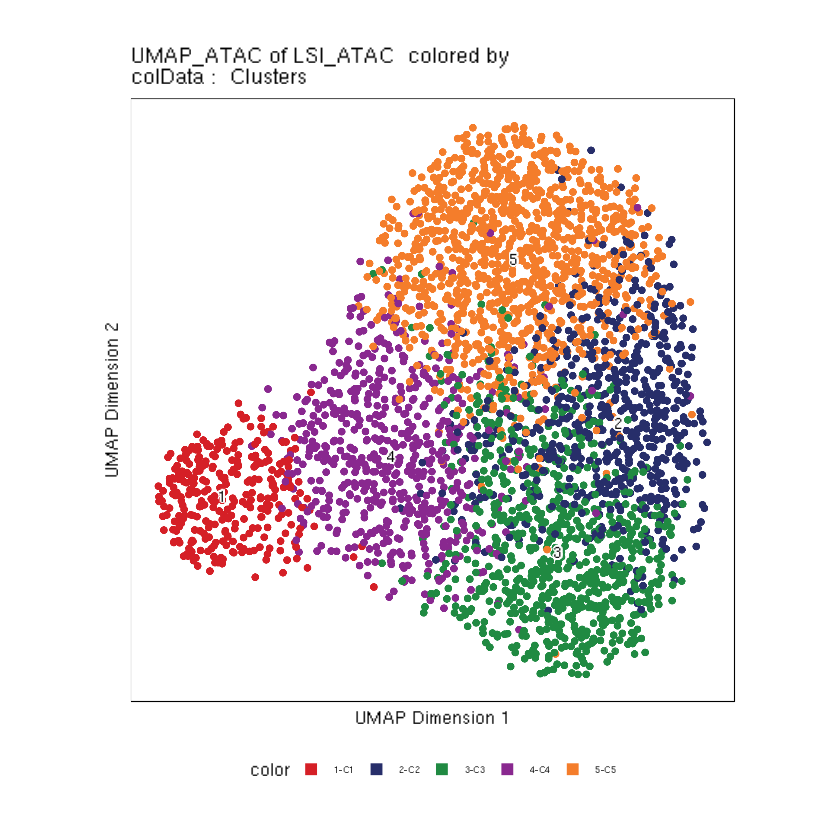

In [9]:
alpha_UMAP <- plotEmbedding(proj_alpha, name = "Clusters", embedding = "UMAP_ATAC", size = 2, labelAsFactors=T, labelMeans=T)
alpha_UMAP

In [10]:
plotPDF(alpha_UMAP, name = "alpha_UMAP", width = 4.5, height = 4.5, addDOC = FALSE)

Plotting Ggplot!



## Marker gene heatmap

In [3]:
seGEX_alpha <- getMarkerFeatures(ArchRProj = proj_alpha, useMatrix = "GeneExpressionMatrix")

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-10245a885db9-Date-2025-08-13_Time-16-24-51.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2025-08-13 16:25:00 : Matching Known Biases, 0.134 mins elapsed.

###########
2025-08-13 16:25:36 : Completed Pairwise Tests, 0.732 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-10245a885db9-Date-2025-08-13_Time-16-24-51.log



In [4]:
subsetSE_GEX_alpha <- seGEX_alpha[which(rowData(seGEX_alpha)$name %in% c(
    "Sv2a", "Prkcd", #Slow-firing
    "Chodl", "Kcnq5", #Fast-firing
    "Atf3", "Gap43", "Hspa9", "Slc7a11" #Degenerating
  )),]

In [5]:
GEX_matrix_alpha <- plotMarkerHeatmap(seMarker = subsetSE_GEX_alpha, log2Norm = FALSE, scaleRows = FALSE, limits = c(-Inf, Inf), returnMatrix = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-102464ccbf5c-Date-2025-08-13_Time-16-25-36.log
If there is an issue, please report to github with logFile!

Identified 8 markers!



[1] "Atf3"    "Gap43"   "Kcnq5"   "Hspa9"   "Slc7a11" "Prkcd"   "Chodl"  
[8] "Sv2a"   


ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-102464ccbf5c-Date-2025-08-13_Time-16-25-36.log



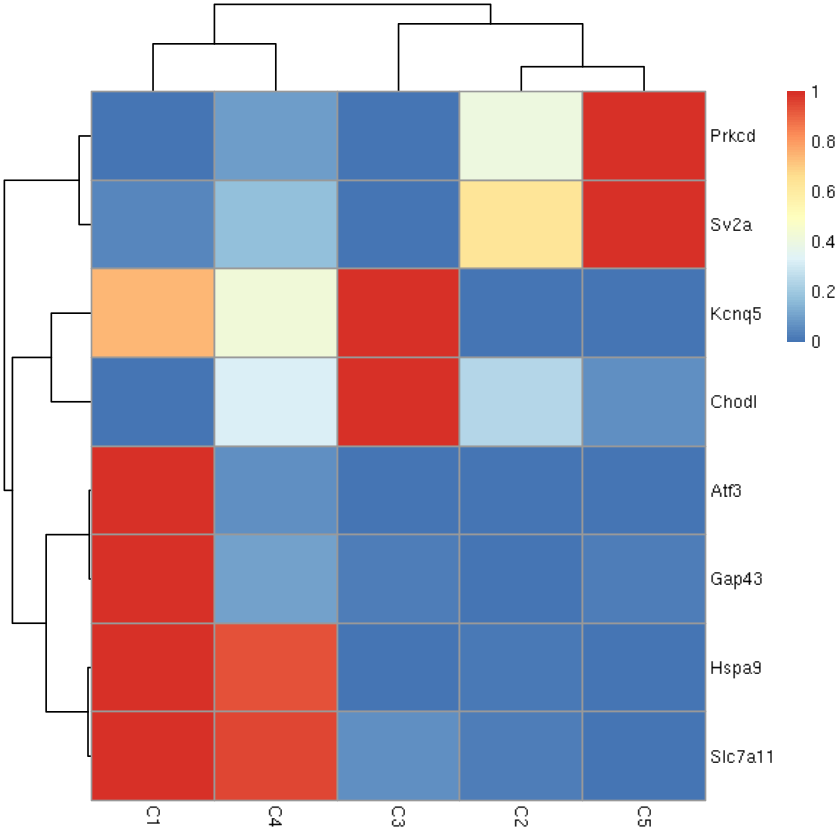

In [6]:
heatmap.avgexp_alpha <- (GEX_matrix_alpha - rowMins(GEX_matrix_alpha))/(rowMaxs(GEX_matrix_alpha) - rowMins(GEX_matrix_alpha))
pheatmap(heatmap.avgexp_alpha)

In [7]:
col_order <- c('C5','C2','C3','C4','C1')
heatmap.avgexp_alpha <- heatmap.avgexp_alpha[,col_order]

row_order <- c('Prkcd','Sv2a','Chodl','Kcnq5','Hspa9','Slc7a11','Atf3','Gap43')
heatmap.avgexp_alpha <- heatmap.avgexp_alpha[row_order,]

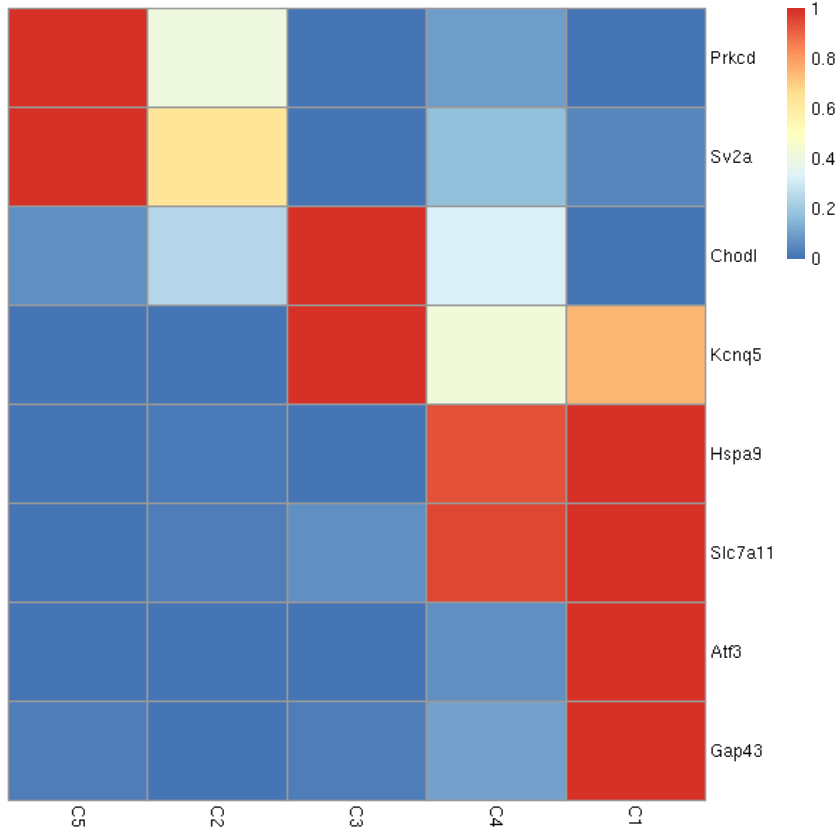

In [8]:
pheatmap(heatmap.avgexp_alpha, cluster_rows = FALSE, cluster_cols = FALSE)

In [9]:
pheatmap(heatmap.avgexp_alpha, cluster_rows = FALSE, cluster_cols = FALSE, filename = 'Figures/multiome_alpha_heatmap_final.pdf', width = 2.0862, height = 2.15, fontsize = 7)

## Add alpha MN subtype annotations

In [2]:
#Load ArchR Project
proj_alpha <- loadArchRProject('proj_alpha')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [13]:
#Add alpha motor neuron subtype annotations
newLabels <- c('Late DAMN', 'Intermediate', 'Fast-Firing',  
               'Early DAMN', 'Slow-Firing')

oldLabels <- c('C1', 'C2', 'C3', 'C4', 'C5')

proj_alpha$alpha_subtype <- mapLabels(proj_alpha$Clusters, newLabels = newLabels, oldLabels = oldLabels)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-c1ce19d77dda-Date-2025-05-27_Time-04-28-58.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-c1ce19d77dda-Date-2025-05-27_Time-04-28-58.log



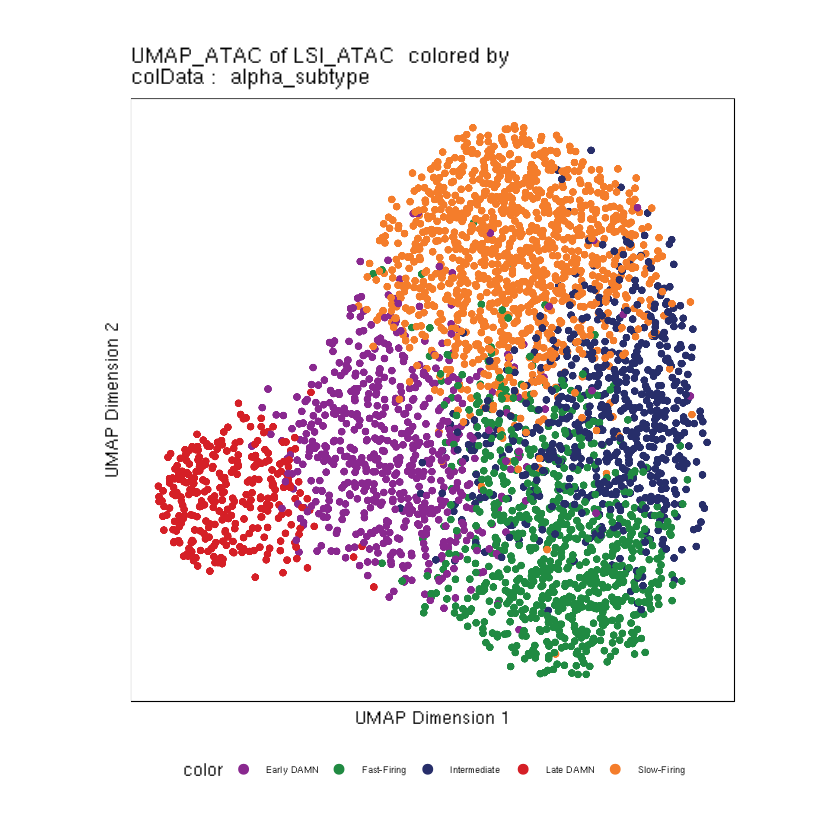

In [7]:
alpha_UMAP_add_annotations <- plotEmbedding(proj_alpha, name = "alpha_subtype", embedding = "UMAP_ATAC", pal = c('#89288F','#208A42','#272E6A','#D51F26','#F47D2B'), size = 2, labelAsFactors=F, labelMeans=F)
alpha_UMAP_add_annotations